In [1]:
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rasterio
from rasterio.transform import Affine
from pathlib import Path

from config import TrainConfig 
from inference_ped import ( InferenceEngine, _load_barangay_band_from_geojson, run_inference )

In [2]:
# ── Visual constants ──────────────────────────────────────────────────────────
FLOOD_COLORS = {0: '#FFFFFF', 1: '#C6DBEF', 2: '#6BAED6', 3: '#2171B5', 4: '#08306B'}
FLOOD_LABELS = {0:'No Flood', 1:'Light', 2:'Moderate', 3:'Heavy', 4:'Extreme'}

# Create colormap with transparent color for class 0
colors_list = ['#FFFFFF', '#C6DBEF', '#6BAED6', '#2171B5', '#08306B']
flood_cmap = mcolors.ListedColormap(colors_list)
flood_cmap.set_under(alpha=0)  
flood_cmap.set_bad(alpha=0)   

legend_patches = [mpatches.Patch(color=FLOOD_COLORS[i], label=FLOOD_LABELS[i]) for i in range(5)]
flood_norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 6)

In [3]:
# ── GeoTIFF save helper ───────────────────────────────────────────────────────
src_left, src_top   = 13457490.0, 1664610.0
src_W,    src_H     = 1125,       1224          
dst_W,    dst_H     = 1152,       1152          
src_right           = 13491240.0
src_bottom          = 1627890.0
new_pixel_x = (src_right  - src_left) / dst_W  
new_pixel_y = (src_bottom - src_top)  / dst_H   
dem_transform = Affine(new_pixel_x, 0.0, src_left, 0.0, new_pixel_y, src_top)
dem_crs       = rasterio.crs.CRS.from_epsg(3857)

_GEOJSON_PATH  = 'manila_barangay_geojson.geojson'
_barangay_band = _load_barangay_band_from_geojson(_GEOJSON_PATH, dem_transform, dem_crs, dst_H, dst_W)
engine = InferenceEngine(patch_data_path = 'outputs/spatial_data.npz')

  Rasterizing 1011 barangays within DEM extent ...
[InferenceEngine] device = cpu
[InferenceEngine] Loaded 6,075 Manila patches  | spatial (6075, 3, 4, 4)  | dem (1152, 1152)
[InferenceEngine] Auto-selected: fold_1_best.pth  (macro_f1=0.4801)
[InferenceEngine] Model loaded  ← fold_1_best.pth



  Predicting: Triangular, 50.0 mm, tpeak=0.5
  Conditioning: pattern_type=3  depth_norm=0.616  tpeak=0.50  has_tpeak=1

  Flooded area : 30.2%  (1,833 / 6,075 patches)
  Mean confidence : 0.778

  Class           Count       %   Avg conf
  ------------------------------------------
  No Flood        4,242   69.8%      0.749
  Light               0    0.0%      0.000
  Moderate           63    1.0%      0.298
  Heavy               4    0.1%      0.384
  Extreme         1,766   29.1%      0.866
  Output directory: input_testing_ped
  Applying mask from manila_box_shape.tif...
  ⚠ Mask alignment: CRS=False, Shape=True
    → Reprojecting mask to match prediction...
  Mask applied: 70,333 / 1,327,104 pixels inside
✓ Saved → input_testing_ped\triangular_50mm_tp05.tif


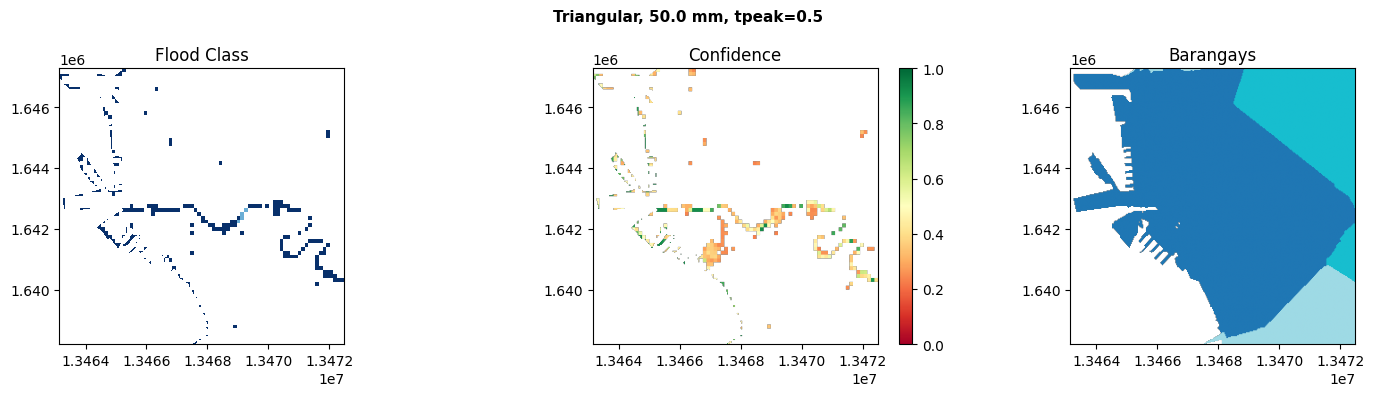

✓ File saved as: triangular_50mm_tp05.tif

✓ File saved (masked) at: input_testing_ped\triangular_50mm_tp05.tif


In [4]:
import os
repo_root = os.getcwd()
manila_mask = os.path.join(repo_root, "manila_box_shape.tif")

res = run_inference(
    engine          = engine,
    storm_type      = 'triangular',
    depth_mm        = 50.0,
    tpeak           = 0.5,
    output_ped_dir  = Path('./input_testing_ped'),
    dem_transform   = dem_transform,
    dem_crs         = dem_crs,
    barangay_band   = _barangay_band,
    mask_tif_path   = manila_mask 
)

print(f"\n✓ File saved (masked) at: {res['tif_path']}")